In [17]:
#1. Сгенерировать с использованием библиотеки pandas csv файл, содержащий 3 столбца: x1 , x2, x3(> 400 строк, генерация с использованием функции linspace). Вид функции определяется вариантом (диапазон выбирается студентом).

import pandas as pd
import numpy as np

n = 500
x1 = np.linspace(-np.pi, np.pi, n)
x2 = np.linspace(-np.pi, np.pi, n)
y = np.cos(x1) * x2**3

df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

df.to_csv('task2.csv', index=False)

print(df.head(3))
print(f"{len(df)} строк")

     x1    x2      y
0 -3.14 -3.14  31.01
1 -3.13 -3.13  30.63
2 -3.12 -3.12  30.26
500 строк


Среднее x1: -0.0000, Среднее x2: -0.0000


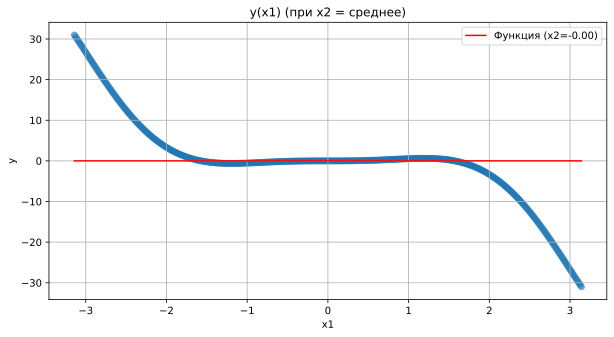

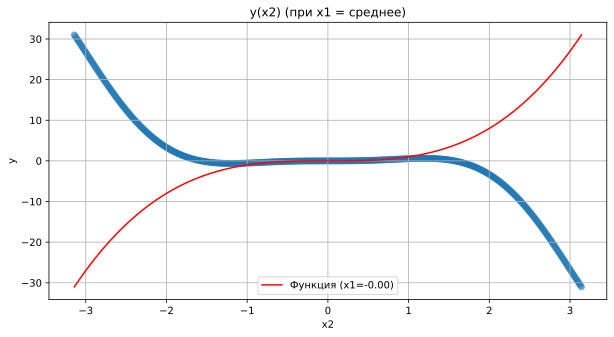

In [29]:
#2.Открыть файл с использованием библиотеки pandas и построить графики. Графики необходимо построить с использованием matplotlib (для функции y отобразить точки на графике).

import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'
pd.set_option("display.precision", 2)

data = pd.read_csv('task2.csv')

# cредние значения
mean_x1 = df['x1'].mean()
mean_x2 = df['x2'].mean()
print(f"Среднее x1: {mean_x1:.4f}, Среднее x2: {mean_x2:.4f}")

# гафик y(x1) + по заданию x2 = mean_x2
plt.figure(figsize=(10, 5))

# точки
plt.scatter(df['x1'], df['y'], alpha=0.5)

# линия функции y = cos(x1) * mean_x2^3
x1_range = np.linspace(-np.pi, np.pi, 100)
y_func_x1 = np.cos(x1_range) * mean_x2**3
plt.plot(x1_range, y_func_x1, 'r-', label=f'Функция (x2={mean_x2:.2f})')

#подписи графиков
plt.xlabel('x1')
plt.ylabel('y')
plt.title('y(x1) (при x2 = среднее)')
plt.legend()
plt.grid(True)
plt.savefig('plot_y_x1.png')
plt.show()

# график y(x2) + по заданию x1 = mean_x1
plt.figure(figsize=(10, 5))

# точки
plt.scatter(df['x2'], df['y'], alpha=0.5)

# линия функции y = cos(mean_x1) * x2^3
x2_range = np.linspace(-np.pi, np.pi, 100)
y_func_x2 = np.cos(mean_x1) * x2_range**3
plt.plot(x2_range, y_func_x2, 'r-', label=f'Функция (x1={mean_x1:.2f})')

plt.xlabel('x2')
plt.ylabel('y')
plt.title('y(x2) (при x1 = среднее)')
plt.legend()
plt.grid(True)
plt.savefig('plot_y_x2.png')
plt.show()

In [31]:
#3.Вывести для каждого столбца : среднее, минимальное и максимальное значения.

# вычисление для каждой строки
df['mean'] = df[['x1', 'x2', 'y']].mean(axis=1) #axis для выч. по строкам
df['min_val'] = df[['x1', 'x2', 'y']].min(axis=1)
df['max_val'] = df[['x1', 'x2', 'y']].max(axis=1)

print(df[['mean', 'min_val', 'max_val']].head(3))  # только первые 3 строчки

   mean  min_val  max_val
0   NaN      NaN      NaN
1   NaN      NaN      NaN
2   NaN      NaN      NaN


In [24]:
#4.
import pandas as pd

df = pd.read_csv('task2.csv')
if 'mean' not in df.columns:
    df['mean'] = df[['x1', 'x2', 'y']].mean(axis=1)
    df['min_val'] = df[['x1', 'x2', 'y']].min(axis=1)
    df['max_val'] = df[['x1', 'x2', 'y']].max(axis=1)

# средние x1 и x2
mean_x1 = df['x1'].mean()
mean_x2 = df['x2'].mean()

# фильтрация: x1 < mean_x1 И x2 < mean_x2
filtered_df = df[(df['x1'] < mean_x1) & (df['x2'] < mean_x2)]

# сохранение в новый CSV
filtered_df.to_csv('filtered.csv', index=False)

print(f"Количество отфильтрованных строк: {len(filtered_df)}")
print(filtered_df.head())  # пример первых строк

Количество отфильтрованных строк: 250
     x1    x2      y  mean  min_val  max_val
0 -3.14 -3.14  31.01  8.24    -3.14    31.01
1 -3.13 -3.13  30.63  8.12    -3.13    30.63
2 -3.12 -3.12  30.26  8.01    -3.12    30.26
3 -3.10 -3.10  29.88  7.89    -3.10    29.88
4 -3.09 -3.09  29.50  7.77    -3.09    29.50


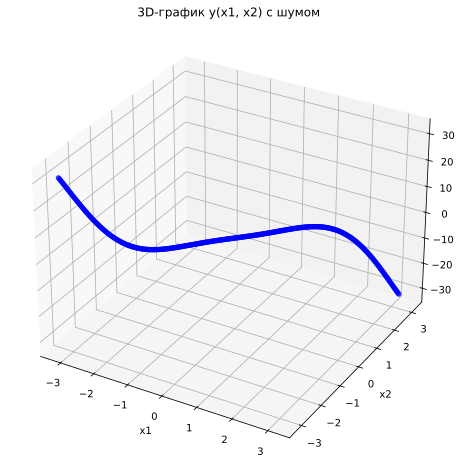

In [28]:
#5 3d график



# 3D-график рассеяния точек (x1, x2, y)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['x1'], df['x2'], df['y'], c='b', alpha=0.6)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D-график y(x1, x2) с шумом')

plt.savefig('3d_plot.png')
plt.show()